In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re,json,nltk
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score
from tensorflow.keras.preprocessing.text import Tokenizer

In [2]:
data = pd.read_csv("/content/Train.csv")
data2 = pd.read_csv("/content/Val.csv")
data = pd.concat([data, data2], ignore_index=True)
data2 = pd.read_csv("/content/Test.csv")
data = pd.concat([data, data2], ignore_index=True)
print(data.shape)
data.head(2)

(15728, 2)


,Data,Label
0,মুগ্ধ হয়ে গেলাম মামু. আর তোমায় কি কমু. বলো তোম...,1
1,এই কুত্তার বাচ্চাদের জন্য দেশটা আজ এমন অবস্তায়...,2


In [ ]:
print("Total reviews:",len(data),
  "\nTotal Positive Reviews:",len(data[data['Label']==1]),
  "\nTotal Neutral Reviews:",len(data[data['Label']==0]),
    "\nTotal Negative Reviews:",len(data[data['Label']==2]))

Total reviews: 15728 
Total Positive Reviews: 6410 
Total Neutral Reviews: 3609 
Total Negative Reviews: 5709


In [3]:
def prcess_comments(Comment):
  Comment = re.sub('[^\u0980-\u09FF]',' ', str(Comment))
  return Comment
data['cleaned'] = data['Data'].apply(prcess_comments)
print(data.shape)
data['length']=data['cleaned'].apply(lambda x:len(x.split()))
dataset = data.loc[data.length>5]
#dataset=data
dataset = dataset.reset_index(drop=True)
print(len(dataset))
dataset= dataset.drop(columns = ['Data'])

(15728, 3)
14168


#Stopwords and punctuation removal

In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
!pip install bangla-stemmer
import bangla_stemmer
from bangla_stemmer.stemmer import stemmer
!pip install bangla-python
import bn
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [5]:


def remove_stopwords(text):
    bangla_stopwords = [
       "এবং","অথবা","কিংবা","তথা",
        "আমি","আমরা","আমার","আমাদের",
        "তুমি","আপনি","আপনার",
        "সে","তিনি","তারা","তাদের",
        "এই","ওই","এটা","ওটা","সেটা",
        "এটি","সেটি",
        "যে","যা","যার","যাদের",
        "যেখানে","যখন",
        "কেউ","কোন","কোনো","কিছু",
        "একটি","একটা","দুটি","কয়েক",
        "থেকে","দিকে","পরে","আগে",
        "উপর","নিচে","মধ্যে",
        "করছে","করেন","করতে","করে",
        "হচ্ছে","হবে","হলো","ছিল",
        "জন্য","সাথে","সঙ্গে",
        "ইত্যাদি","প্রভৃতি"
    ]
    tokens = bn.tokenizer(str(text))
    #tokens = word_tokenize(str(text))
    tokens = [word for word in tokens if word not in bangla_stopwords]

    #bstemmer = stemmer.BanglaStemmer()
    #filtered_words = bstemmer.stem(filtered_words)
    return ' '.join(tokens)
    #return ' '.join(tokens)

dataset['tokens'] = dataset['cleaned'].apply(remove_stopwords)
dataset['processed_text'] =dataset['tokens']

dataset.head(2)

,Label,cleaned,length,tokens,processed_text
0,1,মুগ্ধ হয়ে গেলাম মামু আর তোমায় কি কমু বলো তোম...,22,মুগ্ধ হয়ে গেলাম মামু আর তোমায় কি কমু বলো তোমায়...,মুগ্ধ হয়ে গেলাম মামু আর তোমায় কি কমু বলো তোমায়...
1,2,এই কুত্তার বাচ্চাদের জন্য দেশটা আজ এমন অবস্তায়...,18,কুত্তার বাচ্চাদের দেশটা আজ এমন অবস্তায় তিনটা প...,কুত্তার বাচ্চাদের দেশটা আজ এমন অবস্তায় তিনটা প...


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler

dataset.dropna(subset=['Label'], inplace=True)

X = dataset['processed_text']
y = dataset['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (11334,)
Testing shape: (2834,)


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings('ignore')

##ML Models

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings('ignore')


def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    pred_y = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred_y)
    precision = precision_score(y_test, pred_y, average='weighted')
    recall = recall_score(y_test, pred_y, average='weighted')
    f1 = f1_score(y_test, pred_y, average='weighted')

    print("="*80)
    print(model_name)
    print("="*80)

    print(f"Accuracy : {accuracy*100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, pred_y))



gram_names = ['Unigram', 'Bigram', 'Trigram']

ngrams = [
    (1,1),
    (1,2),
    (1,3)
]


for gram_name, gram_range in zip(gram_names, ngrams):

    print("\n")
    print("#"*100)
    print(f"TF-IDF USING: {gram_name}")
    print("#"*100)

    vectorizer = CountVectorizer(
        ngram_range=gram_range,
        min_df=1,
        binary=True,
        tokenizer=lambda x: x.split(),

)


    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    print("Training Shape Before Oversampling:", X_train_tfidf.shape)
    print("Testing Shape:", X_test_tfidf.shape)

    ros = RandomOverSampler(
        sampling_strategy='auto',
        random_state=42
    )

    X_train_resampled, y_train_resampled = ros.fit_resample(
        X_train_tfidf,
        y_train
    )

    '''
    smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
    )

    X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_tfidf,
    y_train
    )
    '''

    print("Training Shape After Oversampling:", X_train_resampled.shape)

    # MODELS
    models = [

        (
            "Multinomial Naive Bayes",
            MultinomialNB(alpha=0.25, force_alpha=True, fit_prior=True, class_prior=None)
        ),

        (
            "Random Forest",
            RandomForestClassifier(
                n_estimators=100,
                criterion='entropy',
                random_state=42
            )
        ),

        (
            "Decision Tree",
            DecisionTreeClassifier(
                criterion='entropy',
                random_state=42
            )
        ),

        (
            "Logistic Regression",
            LogisticRegression(
                C=2,
                max_iter=1000,
                solver='liblinear',
                class_weight='balanced',
                random_state=0
            )
        ),

        (
            "K-Nearest Neighbors",
            KNeighborsClassifier(
                n_neighbors=5,
                metric='minkowski'
            )
        ),

        (
            "Linear SVM",
            SVC(
                kernel='linear',
                C=1.5,
                probability=True
            )
        ),

        (
            "RBF SVM",
            SVC(
                kernel='rbf',
                C=1000,
                gamma=0.00015,
                probability=True,
                random_state=0
            )
        )
        #grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='accuracy')
        #grid_search.fit(X_train_resampled, y_train_resampled)

    ]


    for model_name, model in models:

        evaluate_model(
            model,
            f"{model_name} ({gram_name})",
            X_train_resampled,
            X_test_tfidf,
            y_train_resampled,
            y_test
        )



####################################################################################################
TF-IDF USING: Unigram
####################################################################################################
Training Shape Before Oversampling: (11334, 22920)
Testing Shape: (2834, 22920)
Training Shape After Oversampling: (13872, 22920)
Multinomial Naive Bayes (Unigram)
Accuracy : 71.10%
Precision: 0.7010
Recall   : 0.7110
F1 Score : 0.7041

Classification Report:

              precision    recall  f1-score   support

           0       0.52      0.41      0.46       617
           1       0.76      0.78      0.77      1157
           2       0.74      0.80      0.77      1060

    accuracy                           0.71      2834
   macro avg       0.67      0.67      0.67      2834
weighted avg       0.70      0.71      0.70      2834

Random Forest (Unigram)
Accuracy : 71.00%
Precision: 0.7118
Recall   : 0.7100
F1 Score : 0.7105

Classification Report:

           

##Language Models

In [ ]:
!pip install -q transformers datasets accelerate evaluate sentencepiece av
import sys
import types


try:
    import torchvision.io
except ImportError:
    pass

mock_module = types.ModuleType("torchvision.io")
sys.modules.setdefault("torchvision.io", mock_module)
setattr(sys.modules["torchvision.io"], "VideoReader", object)
import numpy as np
import pandas as pd

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 38.3 MB/s eta 0:00:00


##BERT BASE 56.32%

In [ ]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(le.classes_)
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/11334 [00:00<?, ? examples/s]

Map:   0%|          | 0/2834 [00:00<?, ? examples/s]

Class weights: tensor([1.5302, 0.8170, 0.8908])


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.034361,0.986333,0.517290,0.561998,0.517290,0.524781
2,0.951679,0.945662,0.563162,0.581205,0.563162,0.569839


BERT-BASE RESULTS
Accuracy : 56.32%
Precision: 0.5812
Recall   : 0.5632
F1 Score : 0.5698

Classification Report

              precision    recall  f1-score   support

           0       0.35      0.44      0.39       617
           1       0.65      0.63      0.64      1157
           2       0.64      0.56      0.60      1060

    accuracy                           0.56      2834
   macro avg       0.55      0.54      0.54      2834
weighted avg       0.58      0.56      0.57      2834


Prediction distribution:
  Class 0: 789
  Class 1: 1116
  Class 2: 929


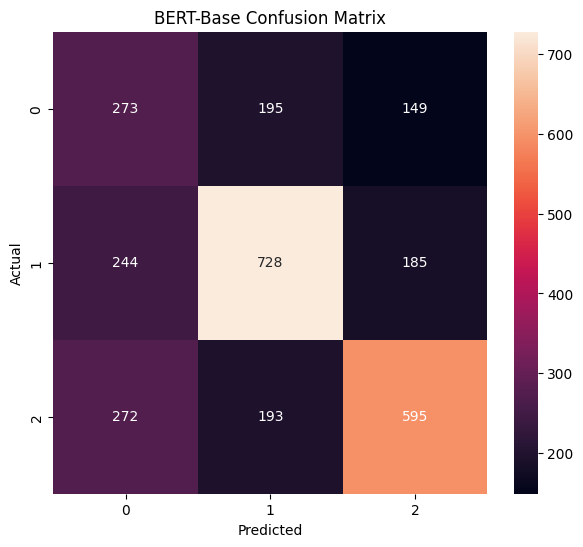

In [ ]:
import torch
from torch import nn

train_df = pd.DataFrame({
    "text": X_train.tolist(),
    "label": y_train_enc
})

test_df = pd.DataFrame({
    "text": X_test.tolist(),
    "label": y_test_enc
})

train_dataset = Dataset.from_pandas(train_df)
test_dataset  = Dataset.from_pandas(test_df)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset  = test_dataset.rename_column("label", "labels")

train_dataset.set_format(type="numpy", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="numpy",  columns=["input_ids", "attention_mask", "labels"])

class_counts = np.bincount(y_train_enc)
class_weights = torch.tensor(
    len(y_train_enc) / (len(class_counts) * class_counts),
    dtype=torch.float
)
print("Class weights:", class_weights)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels.long())
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall":    recall_score(labels, preds, average="weighted", zero_division=0),
        "f1":        f1_score(labels, preds, average="weighted", zero_division=0)
    }

training_args = TrainingArguments(
    output_dir="./bert_output",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    warmup_steps=200,
    logging_steps=100,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

pred_output = trainer.predict(test_dataset)
preds = np.argmax(pred_output.predictions, axis=1)

accuracy  = accuracy_score(y_test_enc, preds)
precision = precision_score(y_test_enc, preds, average='weighted', zero_division=0)
recall    = recall_score(y_test_enc, preds, average='weighted', zero_division=0)
f1        = f1_score(y_test_enc, preds, average='weighted', zero_division=0)

print("="*80)
print("BERT-BASE RESULTS")
print("="*80)
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nClassification Report\n")
print(classification_report(y_test_enc, preds, target_names=le.classes_.astype(str), zero_division=0))

print("\nPrediction distribution:")
unique, counts = np.unique(preds, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {le.inverse_transform([u])[0]}: {c}")

cm = confusion_matrix(y_test_enc, preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT-Base Confusion Matrix")
plt.savefig('/content/BERTBaseResult.jpg', dpi = 400, bbox_inches = 'tight')
plt.show()

##BanglaBERT - 72.09%

In [9]:
MODEL_NAME = "csebuetnlp/banglabert"
MAX_LEN = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(le.classes_)
)

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/528k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/11334 [00:00<?, ? examples/s]

Map:   0%|          | 0/2834 [00:00<?, ? examples/s]

Class weights: tensor([1.5302, 0.8170, 0.8908])


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.782315,0.727829,0.693366,0.729794,0.693366,0.705120
2,0.579093,0.729572,0.720889,0.733998,0.720889,0.726110


BanglaBERT RESULTS
Accuracy : 72.09%
Precision: 0.7340
Recall   : 0.7209
F1 Score : 0.7261

Classification Report

              precision    recall  f1-score   support

           0       0.49      0.58      0.53       617
           1       0.81      0.76      0.78      1157
           2       0.80      0.76      0.78      1060

    accuracy                           0.72      2834
   macro avg       0.70      0.70      0.70      2834
weighted avg       0.73      0.72      0.73      2834


Prediction distribution:
  Class 0: 734
  Class 1: 1086
  Class 2: 1014


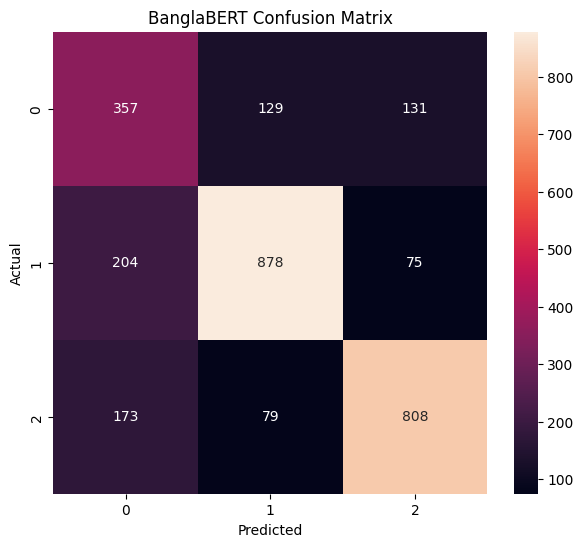

In [ ]:
import torch
from torch import nn

train_df = pd.DataFrame({
    "text": X_train.tolist(),
    "label": y_train_enc
})

test_df = pd.DataFrame({
    "text": X_test.tolist(),
    "label": y_test_enc
})

train_dataset = Dataset.from_pandas(train_df)
test_dataset  = Dataset.from_pandas(test_df)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset  = test_dataset.rename_column("label", "labels")

train_dataset.set_format(type="numpy", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="numpy",  columns=["input_ids", "attention_mask", "labels"])

class_counts = np.bincount(y_train_enc)
class_weights = torch.tensor(
    len(y_train_enc) / (len(class_counts) * class_counts),
    dtype=torch.float
)
print("Class weights:", class_weights)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels.long())
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall":    recall_score(labels, preds, average="weighted", zero_division=0),
        "f1":        f1_score(labels, preds, average="weighted", zero_division=0)
    }

training_args = TrainingArguments(
    output_dir="./banglabert_output",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    warmup_steps=200,
    logging_steps=100,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

pred_output = trainer.predict(test_dataset)
preds = np.argmax(pred_output.predictions, axis=1)

accuracy  = accuracy_score(y_test_enc, preds)
precision = precision_score(y_test_enc, preds, average='weighted', zero_division=0)
recall    = recall_score(y_test_enc, preds, average='weighted', zero_division=0)
f1        = f1_score(y_test_enc, preds, average='weighted', zero_division=0)

print("="*80)
print("BanglaBERT RESULTS")
print("="*80)
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nClassification Report\n")
print(classification_report(y_test_enc, preds, target_names=le.classes_.astype(str), zero_division=0))

print("\nPrediction distribution:")
unique, counts = np.unique(preds, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {le.inverse_transform([u])[0]}: {c}")

cm = confusion_matrix(y_test_enc, preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BanglaBERT Confusion Matrix")
plt.savefig('/content/BanglaBERTResult.jpg', dpi = 400, bbox_inches = 'tight')
plt.show()

##XLM-Roberta: 68.17%

In [ ]:
MODEL_NAME = "xlm-roberta-base"
MAX_LEN = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(le.classes_)
)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/11334 [00:00<?, ? examples/s]

Map:   0%|          | 0/2834 [00:00<?, ? examples/s]

Class weights: tensor([1.5302, 0.8170, 0.8908])


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.794751,0.796322,0.657728,0.685650,0.657728,0.667402
2,0.678183,0.819148,0.681722,0.695854,0.681722,0.687402


XLM-RoBERTa RESULTS
Accuracy : 68.17%
Precision: 0.6959
Recall   : 0.6817
F1 Score : 0.6874

Classification Report

              precision    recall  f1-score   support

           0       0.44      0.53      0.48       617
           1       0.76      0.71      0.74      1157
           2       0.77      0.74      0.75      1060

    accuracy                           0.68      2834
   macro avg       0.66      0.66      0.66      2834
weighted avg       0.70      0.68      0.69      2834


Prediction distribution:
  Class 0: 741
  Class 1: 1080
  Class 2: 1013


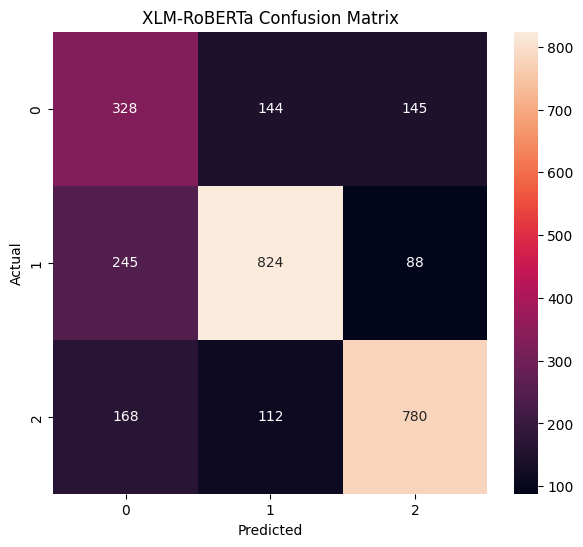

In [ ]:

train_df = pd.DataFrame({
    "text": X_train.tolist(),
    "label": y_train_enc
})

test_df = pd.DataFrame({
    "text": X_test.tolist(),
    "label": y_test_enc
})

train_dataset = Dataset.from_pandas(train_df)
test_dataset  = Dataset.from_pandas(test_df)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset  = test_dataset.rename_column("label", "labels")

train_dataset.set_format(type="numpy", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="numpy",  columns=["input_ids", "attention_mask", "labels"])

class_counts = np.bincount(y_train_enc)
class_weights = torch.tensor(
    len(y_train_enc) / (len(class_counts) * class_counts),
    dtype=torch.float
)
print("Class weights:", class_weights)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels.long())
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall":    recall_score(labels, preds, average="weighted", zero_division=0),
        "f1":        f1_score(labels, preds, average="weighted", zero_division=0)
    }

training_args = TrainingArguments(
    output_dir="./xlmroberta_output",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    warmup_steps=200,
    logging_steps=100,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

pred_output = trainer.predict(test_dataset)
preds = np.argmax(pred_output.predictions, axis=1)

accuracy  = accuracy_score(y_test_enc, preds)
precision = precision_score(y_test_enc, preds, average='weighted', zero_division=0)
recall    = recall_score(y_test_enc, preds, average='weighted', zero_division=0)
f1        = f1_score(y_test_enc, preds, average='weighted', zero_division=0)

print("="*80)
print("XLM-RoBERTa RESULTS")
print("="*80)
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nClassification Report\n")
print(classification_report(y_test_enc, preds, target_names=le.classes_.astype(str), zero_division=0))

print("\nPrediction distribution:")
unique, counts = np.unique(preds, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {le.inverse_transform([u])[0]}: {c}")

cm = confusion_matrix(y_test_enc, preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XLM-RoBERTa Confusion Matrix")
plt.savefig('/content/RobertaResult.jpg', dpi = 400, bbox_inches = 'tight')
plt.show()